** By doing lot of data engineering we can create lot of features but not all features created are useful and not optimal way
- Simplest way to select features would be to remove features with very low variance
- very low variance (i.e. very close to 0), they
are close to being constant and thus, do not add any value to any model at all
- Scikit-learn has an
implementation for VarianceThreshold 

In [5]:
from sklearn.feature_selection import VarianceThreshold
var_thresh = VarianceThreshold(threshold=0.1)
transformed_data = var_thresh.fit_transform(df)
# transformed data will have all columns with variance less
# than 0.1 removed

ValueError: No feature in X meets the variance threshold 0.10000

In [8]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# Small dataset
data = {
    "A": [1, 1, 1, 1, 1],   # Zero variance (constant column)
    "B": [0, 1, 0, 1, 0],   # Some variance
    "C": [10, 11, 10, 11, 10],  # Small variance
    "D": [5, 20, 15, 30, 25]    # Larger variance
}

df = pd.DataFrame(data)
print("Original DataFrame:")
print(df)

# Apply VarianceThreshold
var_thresh = VarianceThreshold(threshold=0.1)  # remove features with variance < 0.1
transformed_data = var_thresh.fit_transform(df)

# Get the selected columns
selected_columns = df.columns[var_thresh.get_support()] #??? get_suppport
df_transformed = pd.DataFrame(transformed_data, columns=selected_columns)

print("\nSelected DataFrame after VarianceThreshold:")
print(df_transformed)


Original DataFrame:
   A  B   C   D
0  1  0  10   5
1  1  1  11  20
2  1  0  10  15
3  1  1  11  30
4  1  0  10  25

Selected DataFrame after VarianceThreshold:
   B   C   D
0  0  10   5
1  1  11  20
2  0  10  15
3  1  11  30
4  0  10  25


In [7]:
df_transformed

,B,C,D
0,0,10,5
1,1,11,20
2,0,10,15
3,1,11,30
4,0,10,25


** - We can also remove high correlation 
- we can use the :-
#### Pearson Correlation

In [15]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# fetch a regression dataset
data=fetch_california_housing()
X=data['data']
col_names=data['feature_names']
y=data['target']
df = pd.DataFrame(X, columns=col_names)
# introduce a highly correlated column
df.loc[:, "MedInc_Sqrt"] = df.MedInc.apply(np.sqrt)
# get correlation matrix (pearson)
df.corr()
 # MedInc_Sqrt has a very high correlation with MedInc

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedInc_Sqrt
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.984329
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,-0.132797
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.326688
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.066910
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,0.018415
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,0.015266
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.084303
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.015569
MedInc_Sqrt,0.984329,-0.132797,0.326688,-0.066910,0.018415,0.015266,-0.084303,-0.015569,1.000000


## Unvariate Feature Selection

- some univariate ways of feature selection. Univariate
feature selection is nothing but a scoring of each feature against a given target
- Mutual information, ANOVA F-test and chi2 are some of the most popular
methods for univariate feature selection.
- There are two ways of using these in scikit-learn.
- - SelectKBest: It keeps the top-k scoring features
- - SelectPercentile: It keeps the top features which are in a percentage
specified by the user

** It must be noted that you can use chi2 only for data which is non-negative in nature.
This is a particularly useful feature selection technique in natural language
processing when we have a bag of words or tf-idf based features

In [17]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import SelectPercentile



class UnivariateFeatureSelection:
    def __init__(self, n_features, problem_type, scoring):
        """
        Custom univariate feature selection wrapper on
        different univariate feature selection models from
        scikit-learn.
        :param n_features: SelectPercentile if float else SelectKBest
        :param problem_type: classification or regression
        :param scoring: scoring function, string
        """
        # for a given problem type, there are only
        # a few valid scoring methods
        # you can extend this with your own custom
        # methods if you wish
        if problem_type == "classification":
            valid_scoring = {
                            "f_classif": f_classif,
                            "chi2": chi2,
                            "mutual_info_classif": mutual_info_classif
                            }
        else:
            valid_scoring = {
                            "f_regression": f_regression,
                            "mutual_info_regression": mutual_info_regression
                            }
        # raise exception if we do not have a valid scoring method
        if scoring not in valid_scoring:
            raise Exception("Invalid scoring function")
        # if n_features is int, we use selectkbest
        # if n_features is float, we use selectpercentile
        # please note that it is int in both cases in sklearn
        if isinstance(n_features, int):
            self.selection = SelectKBest(
                             valid_scoring[scoring],
                             k=n_features
            )
        elif isinstance(n_features, float):
            self.selection = SelectPercentile(
                            valid_scoring[scoring],
                            percentile=int(n_features * 100)
            )
        else:
            raise Exception("Invalid type of feature")
            # same fit function
    def fit(self, X, y):
        return self.selection.fit(X, y)
    # same transform function
    def transform(self, X):
        return self.selection.transform(X)
    # same fit_transform function
    def fit_transform(self, X, y):
        return self.selection.fit_transform(X, y)



In [19]:
ufs = UnivariateFeatureSelection(
n_features=0.1,
problem_type="regression",
scoring="f_regression"
)
ufs.fit(X, y)
X_transformed = ufs.transform(X)

In [20]:
X_transformed

array([[8.3252],
       [8.3014],
       [7.2574],
       ...,
       [1.7   ],
       [1.8672],
       [2.3886]])

** 3) Fit / Transform / Fit-Transform
- ufs.fit(X, y) → computes per-feature scores between each X column and y (using chosen scoring func).
- ufs.transform(X) → returns a NumPy array with only the selected features (like sklearn selectors).
- ufs.fit_transform(X, y) → shorthand for fit then transform.
- Note: transform() returns a NumPy array. If you want a DataFrame with column names, see step 6.

    
** 4) Important practical details & gotchas

- chi2 requires non-negative features (counts or frequencies). If you use chi2, scale or transform inputs (e.g. MinMaxScaler) or avoid negative values.
- f_classif / f_regression are ANOVA/F-test based — work on numeric continuous features.
- mutual_info_* are nonparametric, capture non-linear relationships, often slower but useful.
- If n_features is a float, it must be between 0.0 and 1.0 (converted to percentile *100).
- The selector computes univariate scores — it does not account for feature interactions; good as a fast filter before more expensive models.
- Complexity: very fast — roughly O(n_features × n_samples) for scoring each feature.

** 5) Extra useful attributes after fit

- After ufs.fit(X, y) you can inspect:
- ufs.selection.scores_ — raw scores for each feature (if the scoring function provides)
- ufs.selection.pvalues_ — (for F tests) p-values (if available)
- ufs.selection.get_support() — boolean mask of selected features

** Quick tips

- If you plan to pipeline this into sklearn.pipeline.Pipeline, the fact that transform returns a NumPy array is fine — downstream transformers usually accept arrays. If you want to keep DataFrame columns end-to-end, wrap a small transformer to convert back to DataFrame.
- For reproducibility and clarity, prefer explicit int for top-k (e.g., k=10) or float for percent (e.g., 0.2 → top 20%).
- If you want n_features to be flexible (like "auto"), add a small helper to compute k based on X.shape[1].

** Live toy run with your UnivariateFeatureSelection class so you can see:
- Input data
- Scores computed
- Selected features

In [23]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

# load diabetes regression dataset
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Input shape:", X.shape)
print(X.head())


Input shape: (442, 10)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


In [24]:
ufs = UnivariateFeatureSelection(
    n_features=0.3,                 # keep top 30%
    problem_type="regression", 
    scoring="f_regression"
)

X_trans = ufs.fit_transform(X, y)

print("\nTransformed shape:", X_trans.shape)



Transformed shape: (442, 3)


In [25]:
# mask of which features got selected
mask = ufs.selection.get_support()
selected_cols = X.columns[mask]

# scores for each feature
scores = ufs.selection.scores_

# combine into DataFrame
scores_df = pd.DataFrame({
    "feature": X.columns,
    "score": scores,
    "selected": mask
}).sort_values("score", ascending=False)

print("\nScores with selection flag:")
print(scores_df)

# show only selected features
print("\nSelected features:", list(selected_cols))



Scores with selection flag:
  feature       score  selected
2     bmi  230.653764      True
8      s5  207.271194      True
3      bp  106.520131      True
7      s4  100.069264     False
6      s3   81.239659     False
9      s6   75.399683     False
4      s1   20.710567     False
0     age   16.101374     False
5      s2   13.746079     False
1     sex    0.817423     False

Selected features: ['bmi', 'bp', 's5']


### Greedy feature selection

- the first step is to choose a
model. 
- The second step is to select a loss/scoring function. 
- And the third and final
step is to iteratively evaluate each feature and add it to the list of “good” features if
it improves loss/score.
- This feature selection process
will fit a given model each time it evaluates a feature. The computational cost
associated with this kind of method is very high. It will also take a lot of time for
this kind of feature selection to finish. And if you do not use this feature selection
properly, then you might even end up overfitting the model.

In [26]:
# greedy.py
import pandas as pd
from sklearn import linear_model
from sklearn import metrics
from sklearn.datasets import make_classification
class GreedyFeatureSelection:
    """
    A simple and custom class for greedy feature selection.
    You will need to modify it quite a bit to make it suitable
    for your dataset.
    """
    def evaluate_score(self, X, y):
        """
        This function evaluates model on data and returns
        Area Under ROC Curve (AUC)
        NOTE: We fit the data and calculate AUC on same data.
        WE ARE OVERFITTING HERE.
        But this is also a way to achieve greedy selection.
        k-fold will take k times longer.
        If you want to implement it in really correct way,
        calculate OOF AUC and return mean AUC over k folds.
        This requires only a few lines of change and has been
        shown a few times in this book.
        :param X: training data
        :param y: targets
        :return: overfitted area under the roc curve
        """
        # fit the logistic regression model,
        # and calculate AUC on same data
        # again: BEWARE
        # you can choose any model that suits your data
        model = linear_model.LogisticRegression()
        model.fit(X, y)
        predictions = model.predict_proba(X)[:, 1]
        auc = metrics.roc_auc_score(y, predictions)
        return auc

    def _feature_selection(self, X, y):
        """
        This function does the actual greedy selection
        :param X: data, numpy array
        :param y: targets, numpy array
        :return: (best scores, best features)
        """
        # initialize good features list
        # and best scores to keep track of both
        good_features = []
        best_scores = []
        # calculate the number of features
        num_features = X.shape[1]
        # infinite loop
        while True:
        # initialize best feature and score of this loop
            this_feature = None
            best_score = 0
        # loop over all features
            for feature in range(num_features):
            # if feature is already in good features,
            # skip this for loop
                if feature in good_features:
                    continue
            # selected features are all good features till now
            # and current feature
                selected_features = good_features + [feature]
            # remove all other features from data
                xtrain = X[:, selected_features]
            # calculate the score, in our case, AUC
                score = self.evaluate_score(xtrain, y)
            # if score is greater than the best score
            # of this loop, change best score and best feature
                if score > best_score:
                    this_feature = feature
                    best_score = score
            # if we have selected a feature, add it
            
            
            # to the good feature list and update best scores list
            if this_feature != None:
                good_features.append(this_feature)
                best_scores.append(best_score)
            # if we didnt improve during the previous round,
            # exit the while loop
            if len(best_scores) > 2:
                if best_scores[-1] < best_scores[-2]:
                    break
            # return best scores and good features
            # why do we remove the last data point?
        return best_scores[:-1], good_features[:-1]
        
    def __call__(self, X, y):
        """
        Call function will call the class on a set of arguments
        """
        # select features, return scores and selected indices
        scores, features = self._feature_selection(X, y)
        # transform data with selected features
        return X[:, features], scores
        
if __name__ == "__main__":
    # generate binary classification data
    X, y = make_classification(n_samples=1000, n_features=100)
    # transform data by greedy feature selection
    X_transformed, scores = GreedyFeatureSelection()(X, y)
    print("Selected features shape:", X_transformed.shape)
    print("Scores:", scores)



# ====== if you want to see auc for each feature as descirbed in below terminal result
# # greedy.py
# import pandas as pd
# from sklearn import linear_model
# from sklearn import metrics
# from sklearn.datasets import make_classification


# class GreedyFeatureSelection:
#     """
#     A simple and custom class for greedy feature selection.
#     """

#     def evaluate_score(self, X, y):
#         """Train Logistic Regression and return AUC score"""
#         model = linear_model.LogisticRegression(max_iter=1000)
#         model.fit(X, y)
#         predictions = model.predict_proba(X)[:, 1]
#         auc = metrics.roc_auc_score(y, predictions)
#         return auc

#     def _feature_selection(self, X, y):
#         """Greedy forward feature selection"""
#         good_features = []
#         best_scores = []
#         num_features = X.shape[1]

#         while True:
#             this_feature = None
#             best_score = 0

#             for feature in range(num_features):
#                 if feature in good_features:
#                     continue

#                 selected_features = good_features + [feature]
#                 xtrain = X[:, selected_features]
#                 score = self.evaluate_score(xtrain, y)

#                 if score > best_score:
#                     this_feature = feature
#                     best_score = score

#             if this_feature is not None:
#                 good_features.append(this_feature)
#                 best_scores.append(best_score)

#                 # 👀 Print progress
#                 print(f"Selected feature {this_feature} | AUC = {best_score:.4f}")
#             else:
#                 break

#             if len(best_scores) > 2:
#                 if best_scores[-1] < best_scores[-2]:
#                     print("⚠️ Score decreased, stopping selection.")
#                     break

#         return best_scores[:-1], good_features[:-1]

#     def __call__(self, X, y):
#         scores, features = self._feature_selection(X, y)
#         return X[:, features], scores


# if __name__ == "__main__":
#     # Generate dummy dataset
#     X, y = make_classification(n_samples=500, n_features=20, random_state=42)

#     # Run greedy feature selection
#     X_transformed, scores = GreedyFeatureSelection()(X, y)

#     print("\n✅ Final Selected Features:", scores)


Selected features shape: (1000, 43)
Scores: [0.941507766031064, 0.9431917727670911, 0.9440357761431046, 0.944875779503118, 0.9456237824951299, 0.9460637842551369, 0.9465557862231448, 0.9471517886071543, 0.9477037908151633, 0.9481277925111701, 0.9484917939671758, 0.9489277957111828, 0.9493837975351902, 0.9499757999031995, 0.9503438013752055, 0.9506998027992113, 0.9510598042392169, 0.9514678058712234, 0.9517638070552282, 0.9521238084952339, 0.9524478097912391, 0.9527678110712443, 0.9530918123672495, 0.9534078136312546, 0.9537838151352604, 0.9539718158872634, 0.9541838167352669, 0.95436781747127, 0.9544878179512718, 0.9546798187192749, 0.9548438193752774, 0.9549838199352797, 0.9551638206552826, 0.9553598214392858, 0.9555118220472881, 0.9556318225272901, 0.9556958227832911, 0.9557158228632915, 0.9558558234232936, 0.9559158236632945, 0.9560198240792964, 0.9560518242072968, 0.9560918243672974]


In [ ]:
(ml) ➜  mnist_classifier git:(main) ✗ python -W ignore src/greedy.py

Selected feature 15 | AUC = 0.9455
Selected feature 0 | AUC = 0.9475
Selected feature 6 | AUC = 0.9488
Selected feature 19 | AUC = 0.9503
Selected feature 13 | AUC = 0.9523
Selected feature 1 | AUC = 0.9528
Selected feature 18 | AUC = 0.9532
Selected feature 14 | AUC = 0.9535
Selected feature 17 | AUC = 0.9537
Selected feature 11 | AUC = 0.9541
Selected feature 9 | AUC = 0.9542
Selected feature 10 | AUC = 0.9543
Selected feature 4 | AUC = 0.9543
⚠️ Score decreased, stopping selection.

✅ Final Selected Features: [0.9455191283060529, 0.9475031600505608, 0.9487671802748843, 0.9503352053632859, 0.9523192371077938, 0.9528152450439206, 0.9531672506760108, 0.9534872557960926, 0.9537112593801501, 0.9540632650122401, 0.954207267316277, 0.9542872685962976]

### Recursive feature elimination (RFE)

- In the previous method, we started with one feature and kept adding new features, but in RFE, we start with all features and keep removing one feature in every iteration that provides the least value to a given model.
- But how to do we know which feature
offers the least value?
- Well, if we use models like linear support vector machine
(SVM) or logistic regression, we get a coefficient for each feature which decides
the importance of the features
- In case of any tree-based models, we get feature
importance in place of coefficients
- In each iteration, we can eliminate the least important feature and keep eliminating it until we reach the number of features
needed
- When we are doing recursive feature elimination, in each iteration, we remove the
feature which has the feature importance or the feature which has a coefficient
close to 0. Please remember that when you use a model like logistic regression for
binary classification, the coefficients for features are more positive if they are
important for the positive class and more negative if they are important for the
negative class. It’s very easy to modify our greedy feature selection class to create
a new class for recursive feature elimination, but scikit-learn also provides RFE
out of the box.

In [28]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

# fetch regression dataset
data=fetch_california_housing()
X=data['data']
col_names=data['feature_names']
y=data['target']

#initialize the model
model=LinearRegression()
# initialize RFE
rfe=RFE(estimator=model,
        n_features_to_select=3)
# fit RFE
rfe.fit(X,y)
#get the transformed data with
# selected columns
X_transformed=rfe.transform(X)

In [32]:
print(X[2])

[   7.2574       52.            8.28813559    1.07344633  496.
    2.80225989   37.85       -122.24      ]


In [33]:
print(X_transformed[2])

[   7.2574   37.85   -122.24  ]


- But you can also
fit the model to the data and select features from the model by the feature
coefficients or the importance of features. If you use coefficients, you can select
a threshold, and if the coefficient is above that threshold, you can keep the feature
else eliminate it.

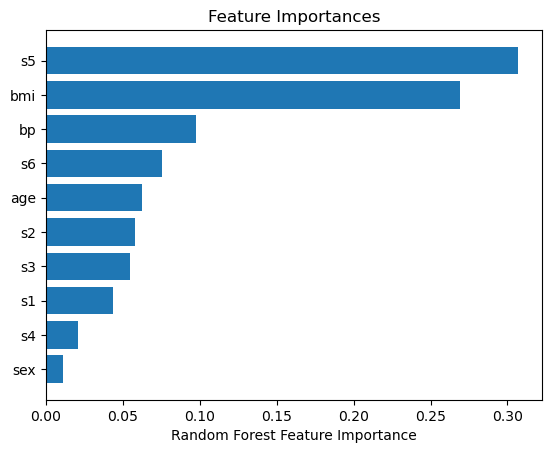

In [36]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
# fetch regression dataset
# in diabetes data we predict diabetes progression
# after one year based on some features
data=load_diabetes()
X=data['data']
col_names=data['feature_names']
y=data['target']
#initialize the model
model=RandomForestRegressor()
#fit the model
model.fit(X,y)
importances = model.feature_importances_
idxs = np.argsort(importances)
plt.title('Feature Importances')
plt.barh(range(len(idxs)), importances[idxs], align='center')
plt.yticks(range(len(idxs)), [col_names[i] for i in idxs])
plt.xlabel('Random Forest Feature Importance')
plt.show()

### Feature from one model to other
- You can choose
features from one model and use another model to train. For example, you can use
Logistic Regression coefficients to select the features and then use Random Forest
to train the model on chosen features. Scikit-learn also offers SelectFromModel
class that helps you choose features directly from a given model. You can also
specify the threshold for coefficients or feature importance if you want and the
maximum number of features you want to select.

In [39]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
# fetch a regression dataset
# in diabetes data we predict diabetes progression
# after one year based on some features
data = load_diabetes()
X = data["data"]
col_names = data["feature_names"]
y = data["target"]
# initialize the model
model = RandomForestRegressor()
# select from the model
sfm = SelectFromModel(estimator=model)
X_transformed = sfm.fit_transform(X, y)
# see which features were selected
support = sfm.get_support()
# get feature names
print([
x for x, y in zip(col_names, support) if y == True
])

['bmi', 's5']


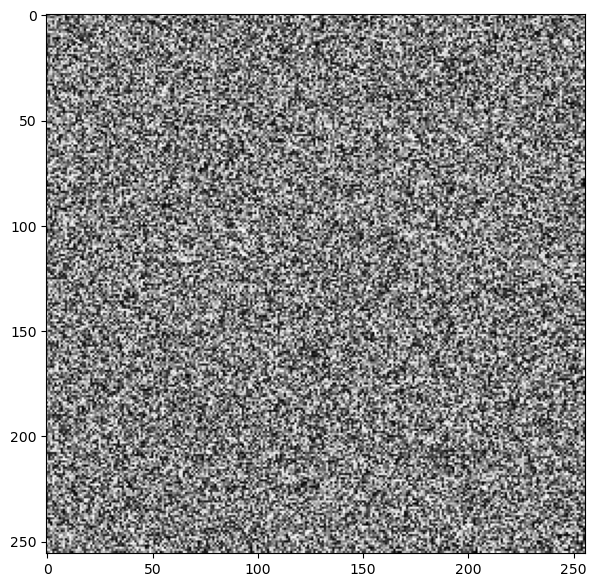